# Численное моделирование распространения сейсмических волн в двумерной среде MILEN SEM 2D. Часть первая.

## Глава V: Переработка структуры слоев модели

## Задача 1


Обновить геологическую модель на основе новых данных о слоях из каротажных скважин.

Задачи:
1. Парсинг новых слоев из файла wells_geometry_sketch_corr_.xlsx
2. Построение геометрии слоев по поверхности между скважинами

In [26]:
# Импорты
import pandas as pd
import openpyxl
from pathlib import Path
from typing import List, Dict, Any

### 1. Парсинг геологических слоев ##

In [27]:
def parse_geological_layers(excel_file: str) -> List[Dict[str, Any]]:
    """
    Парсинг геологических слоев из Excel файла с выделением жирным шрифтом.

    Функция анализирует файл wells_geometry_sketch_corr_.xlsx и определяет границы
    геологических слоев на основе жирного шрифта в ячейках. Жирным шрифтом выделены
    последние ячейки каждого слоя.

    Args:
        excel_file: Путь к Excel файлу

    Returns:
        Список словарей с информацией о слоях в формате:
        [{
            'formation': str,  # Название породы
            'well1_depth': int, # Глубина границы слоя для скважины 1
            'well2_depth': int  # Глубина границы слоя для скважины 2
        }, ...]
    """
    # Загружаем workbook
    wb = openpyxl.load_workbook(excel_file)
    ws = wb.active

    # Собираем информацию о жирных ячейках для каждой скважины
    well1_layers = []
    well2_layers = []

    # Проходим по всем строкам с данными
    for row in range(2, ws.max_row + 1):  # Начиная со второй строки (после заголовков)
        depth = ws[f'A{row}'].value
        formation1 = ws[f'B{row}'].value
        formation2 = ws[f'C{row}'].value

        # Проверяем жирный шрифт
        if ws[f'B{row}'].font.bold:
            well1_layers.append({
                'formation': formation1,
                'well1_depth': depth,
                'well2_depth': None  # Будет заполнено позже
            })

        if ws[f'C{row}'].font.bold:
            well2_layers.append({
                'formation': formation2,
                'well1_depth': None,  # Будет заполнено позже
                'well2_depth': depth
            })

    # Создаем пары слоев: каждая пара соответствует одному слою
    # Берем жирные ячейки Well1 и Well2 последовательно
    layers_data = []

    # Сортируем слои по глубине
    well1_layers_sorted = sorted(well1_layers, key=lambda x: x['well1_depth'])
    well2_layers_sorted = sorted(well2_layers, key=lambda x: x['well2_depth'])

    # Создаем пары (предполагаем, что количество жирных ячеек одинаковое)
    for i in range(len(well1_layers_sorted)):
        layer1 = well1_layers_sorted[i]
        layer2 = well2_layers_sorted[i] if i < len(well2_layers_sorted) else None

        # Используем formation из Well1 (или Well2, если Well1 недоступен)
        formation = layer1['formation']

        layers_data.append({
            'formation': formation,
            'well1_depth': layer1['well1_depth'],
            'well2_depth': layer2['well2_depth'] if layer2 else None
        })

    return layers_data

In [28]:
# Выполнение парсинга
excel_path = Path("src") / "wells_geometry_sketch_corr_.xlsx"
geo_layers_in_wells = parse_geological_layers(str(excel_path))

print(f"Найдено {len(geo_layers_in_wells)} геологических слоев")
print("Пример первых 10 слоев:")
for i, layer in enumerate(geo_layers_in_wells[:10], 1):
    print(f"{i:2d}. {layer}")

if len(geo_layers_in_wells) > 10:
    print(f"... и еще {len(geo_layers_in_wells) - 10} слоев")

Найдено 75 геологических слоев
Пример первых 10 слоев:
 1. {'formation': 'песчаник', 'well1_depth': 10, 'well2_depth': 10}
 2. {'formation': 'песчаник', 'well1_depth': 30, 'well2_depth': 30}
 3. {'formation': 'песчаник', 'well1_depth': 60, 'well2_depth': 60}
 4. {'formation': 'песчаник', 'well1_depth': 100, 'well2_depth': 90}
 5. {'formation': 'песчаник', 'well1_depth': 120, 'well2_depth': 110}
 6. {'formation': 'песчаник', 'well1_depth': 140, 'well2_depth': 130}
 7. {'formation': 'песчаник', 'well1_depth': 160, 'well2_depth': 150}
 8. {'formation': 'песчаник', 'well1_depth': 180, 'well2_depth': 170}
 9. {'formation': 'песчаник', 'well1_depth': 230, 'well2_depth': 190}
10. {'formation': 'глина', 'well1_depth': 270, 'well2_depth': 230}
... и еще 65 слоев


### Результаты парсинга ##

Парсинг завершен успешно. Получено ровно 75 геологических слоев, что соответствует
количеству жирных ячеек в каждой скважине.

Каждый слой содержит:
- formation: название породы
- well1_depth: глубина границы слоя в скважине 1
- well2_depth: глубина границы слоя в скважине 2

Эти данные можно использовать для построения геометрии слоев между скважинами.

### Выводы

В первой задаче главы V был выполнен парсинг геологических слоев из файла wells_geometry_sketch_corr_.xlsx.

Были выполнены следующие задачи:
1. Анализ Excel файла с выделением жирным шрифтом границ слоев
2. Парсинг названий формаций и глубин границ для обеих скважин
3. Создание структурированного списка из 75 геологических слоев

Результаты будут использованы в следующей задаче для построения геометрии слоев между скважинами.

## Задача 2

Получить геометрические данные сечений поверхностей слоев с использованием квадратичного сплайна.

Алгоритм:
- Используются фиксированные Z-координаты сейсмических поверхностей
- Границы слоев строятся через квадратичный сплайн по четырем точкам
- Области между слоями заливаются цветами соответствующих формаций

Задачи:
1. Загрузить данные геологических слоев из dev_1_5_1_layer_update.py
2. Загрузить сейсмические поверхности из data/dev_1_2_profile_sections_depths.npz
3. Создать функции конвертации между локальными и глобальными координатами
4. Построить границы слоев с квадратичным сплайном
5. Сохранить результаты и визуализировать

In [29]:
# Импорты
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from typing import List, Dict, Any
import sys
from scipy import interpolate

# Добавляем путь для импорта из part5_layer_update_1.py
sys.path.append('.')

### 1. Загрузка данных ##

In [30]:
# Загружаем данные сейсмических поверхностей
profile_data = np.load('data/dev_1_2_profile_sections_depths.npz')
profile_depths_all = profile_data['profile_depths']
distances = profile_data['distances']

# Переупорядочиваем поверхности
profile_depths = profile_depths_all[:, [0,9,10,4,3,5,6,7,2,8,1]]

# Фиксированные Z-координаты для каждой поверхности
surface_z_coords = np.array([9, 18, 34, 42, 49, 89, 138, 167, 230, 235, 249])

print(f"Загружены сейсмические поверхности: {profile_depths.shape}")
print(f"Расстояния вдоль профиля: от {distances[0]:.0f} до {distances[-1]:.0f} м")
print(f"Фиксированные Z-координаты поверхностей: {surface_z_coords}")

# Координаты скважин
WELL1_DISTANCE = 4250  # м от начала профиля
WELL2_DISTANCE = 7500  # м от начала профиля

print(f"Скважина 1: {WELL1_DISTANCE} м от начала профиля")
print(f"Скважина 2: {WELL2_DISTANCE} м от начала профиля")

Загружены сейсмические поверхности: (1176, 11)
Расстояния вдоль профиля: от 0 до 11750 м
Фиксированные Z-координаты поверхностей: [  9  18  34  42  49  89 138 167 230 235 249]
Скважина 1: 4250 м от начала профиля
Скважина 2: 7500 м от начала профиля


### 2. Функции конвертации координат ##

In [31]:
def local_to_global_depth(G: np.ndarray, Z: float, z_coords: np.ndarray = surface_z_coords) -> float:
    """
    Вычисляет глобальную глубину D из локальной координаты Z с учетом фиксированных Z-поверхностей.

    Z - локальная координата, которая интерполируется между фиксированными z_coords.
    Например, если Z = 100, и z_coords = [9, 18, 34, 42, 49, 89, 138, 167, 230, 235, 249],
    то 100 находится между 89 (индекс 5) и 138 (индекс 6).
    Расстояние от 89: 100-89=11, от 138: 138-100=38
    D = (G[5]*38 + G[6]*11) / (11+38)

    Args:
        G: Массив из 11 значений глубины сейсмических поверхностей в данной точке
        Z: Локальная координата
        z_coords: Фиксированные Z-координаты поверхностей

    Returns:
        D: Глобальная глубина
    """
    if Z <= z_coords[0]:
        return G[0]
    elif Z >= z_coords[-1]:
        return G[-1]

    # Находим между какими z_coords находится Z
    for i in range(len(z_coords) - 1):
        if z_coords[i] <= Z <= z_coords[i + 1]:
            # Расстояния до границ интервала
            dist_to_lower = Z - z_coords[i]
            dist_to_upper = z_coords[i + 1] - Z
            total_dist = dist_to_lower + dist_to_upper

            if total_dist > 0:
                # Интерполяция
                return (G[i] * dist_to_upper + G[i + 1] * dist_to_lower) / total_dist
            else:
                return G[i]

    # Если не нашли, возвращаем последнюю поверхность
    return G[-1]

In [32]:
def global_to_local_depth(G: np.ndarray, D: float, z_coords: np.ndarray = surface_z_coords) -> float:
    """
    Вычисляет локальную координату Z из глобальной глубины D.
    Это обратная функция к local_to_global_depth.

    Args:
        G: Массив из 11 значений глубины сейсмических поверхностей в данной точке
        D: Глобальная глубина
        z_coords: Фиксированные Z-координаты поверхностей

    Returns:
        Z: Локальная координата
    """
    # Проверяем границы
    if D <= G[0]:
        return z_coords[0]
    elif D >= G[-1]:
        return z_coords[-1]

    # Находим между какими поверхностями находится D
    for i in range(len(G) - 1):
        if G[i] <= D <= G[i + 1]:
            # Линейная интерполяция в пространстве Z
            if G[i + 1] == G[i]:
                return z_coords[i]  # Если поверхности совпадают
            else:
                fraction = (D - G[i]) / (G[i + 1] - G[i])
                return z_coords[i] + fraction * (z_coords[i + 1] - z_coords[i])

    # Если не нашли, возвращаем последнюю Z
    return z_coords[-1]

### 3. Загрузка геологических слоев ###

In [33]:
# Загружаем геологические слои
excel_path = Path("src") / "wells_geometry_sketch_corr_.xlsx"
geo_layers_in_wells = parse_geological_layers(str(excel_path))

print(f"\nЗагружено {len(geo_layers_in_wells)} геологических слоев")
print("Примеры слоев:")
for i, layer in enumerate(geo_layers_in_wells[:5], 1):
    print(f"  {i}. {layer['formation']:15} well1={layer['well1_depth']} well2={layer['well2_depth']}")


Загружено 75 геологических слоев
Примеры слоев:
  1. песчаник        well1=10 well2=10
  2. песчаник        well1=30 well2=30
  3. песчаник        well1=60 well2=60
  4. песчаник        well1=100 well2=90
  5. песчаник        well1=120 well2=110


### 4. Построение линий границ слоев ###

In [34]:
def build_layer_boundary_line(layer: Dict[str, Any], profile_depths: np.ndarray,
                            distances: np.ndarray, well1_dist: float, well2_dist: float,
                            z_coords: np.ndarray) -> np.ndarray:
    """
    Строит линию границы слоя на основе данных из скважин с использованием фиксированных Z-координат.

    Args:
        layer: Словарь с данными слоя {'formation', 'well1_depth', 'well2_depth'}
        profile_depths: Массив сейсмических поверхностей (1176, 11)
        distances: Массив расстояний вдоль профиля (1176,)
        well1_dist: Расстояние до скважины 1
        well2_dist: Расстояние до скважины 2
        z_coords: Фиксированные Z-координаты поверхностей

    Returns:
        boundary_depths: Массив глубин границы слоя (1176,)
    """
    # Находим индексы ближайших точек к скважинам
    well1_idx = np.argmin(np.abs(distances - well1_dist))
    well2_idx = np.argmin(np.abs(distances - well2_dist))

    # Получаем глобальные глубины в скважинах
    well1_global_depth = layer['well1_depth']
    well2_global_depth = layer['well2_depth']

    if well1_global_depth is None or well2_global_depth is None:
        # Создаем массив NaN для слоев с неполными данными
        return np.full(len(distances), np.nan)

    # Вычисляем локальные координаты в скважинах
    well1_profile_G = profile_depths[well1_idx]  # 11 значений глубины в точке well1
    well2_profile_G = profile_depths[well2_idx]  # 11 значений глубины в точке well2

    Z1 = global_to_local_depth(well1_profile_G, well1_global_depth, z_coords)
    Z2 = global_to_local_depth(well2_profile_G, well2_global_depth, z_coords)

    # Строим гладкую сплайновую кривую через четыре точки:
    # (0, Z1), (well1_dist, Z1), (well2_dist, Z2), (profile_total_length, Z2)

    # Определяем четыре ключевые точки для сплайна
    spline_x = np.array([0, well1_dist, well2_dist, distances[-1]])
    spline_z = np.array([Z1, Z1, Z2, Z2])

    # Создаем квадратичный сплайн
    try:
        spline = interpolate.interp1d(spline_x, spline_z, kind='quadratic',
                                    bounds_error=False, fill_value='extrapolate')
        boundary_Z = spline(distances)
    except:
        # Fallback на линейную интерполяцию, если сплайн не получается
        print(f"  Предупреждение: не удалось создать сплайн для слоя, использую линейную интерполяцию")
        boundary_Z = np.interp(distances, spline_x, spline_z)

    # Конвертируем локальные координаты обратно в глобальные глубины
    boundary_depths = np.zeros(len(distances))

    for i in range(len(distances)):
        G_at_point = profile_depths[i]  # 11 значений глубины в точке i
        boundary_depths[i] = local_to_global_depth(G_at_point, boundary_Z[i], z_coords)

    return boundary_depths

In [35]:
# Строим границы для всех слоев
layer_boundaries = []

print("\n" + "="*60)
print("ПОСТРОЕНИЕ ГРАНИЦ СЛОЕВ")
print("="*60)

for i, layer in enumerate(geo_layers_in_wells):  # Обрабатываем все слои
    if (i + 1) % 10 == 0:  # Показываем прогресс каждые 10 слоев
        print(f"Обработано {i+1}/{len(geo_layers_in_wells)} слоев...")

    boundary = build_layer_boundary_line(
        layer, profile_depths, distances, WELL1_DISTANCE, WELL2_DISTANCE, surface_z_coords
    )

    layer_boundaries.append({
        'formation': layer['formation'],
        'well1_depth': layer['well1_depth'],
        'well2_depth': layer['well2_depth'],
        'boundary_depths': boundary
    })

print(f"\nОбработано {len(layer_boundaries)} слоев")

layer_boundaries_array = np.array([layer['boundary_depths'] for layer in layer_boundaries])


ПОСТРОЕНИЕ ГРАНИЦ СЛОЕВ
Обработано 10/75 слоев...
Обработано 20/75 слоев...
Обработано 30/75 слоев...
Обработано 40/75 слоев...
Обработано 50/75 слоев...
Обработано 60/75 слоев...
Обработано 70/75 слоев...

Обработано 75 слоев


Удобнее кодировать наши слои в виде их толщин по z:

In [36]:
layer_boundaries_array_zer = np.concatenate([
    np.zeros((1, layer_boundaries_array.shape[1])), 
    layer_boundaries_array
])

layers_depth = np.diff(layer_boundaries_array_zer, axis=0)

Посмотрим, хорошо ли сработала интерполяция

In [37]:
for i, row in enumerate(layers_depth):
    min_val = np.min(row)
    max_val = np.max(row)
    if min_val < 10:
        print(f"Слой {i}: min = {min_val}, max = {max_val}")

Слой 0: min = 9.301043702025579, max = 11.526817978887557
Слой 15: min = 9.204799356542878, max = 10.85740390364316
Слой 23: min = 9.868684185213283, max = 10.301340622156545
Слой 27: min = 5.183916763112734, max = 35.5310460003451
Слой 28: min = 9.848177054302027, max = 10.194087873545527
Слой 39: min = 7.797730059644891, max = 22.345056232139314
Слой 41: min = 9.876368716619481, max = 10.166004967446952
Слой 43: min = 9.876368716619027, max = 10.166004967446952
Слой 59: min = 9.588392136507991, max = 10.369764740855317
Слой 62: min = 6.965080948113155, max = 22.054101551681015
Слой 63: min = 6.965080948113155, max = 22.054101551681015
Слой 64: min = 7.122001864625872, max = 13.904192231872003
Слой 65: min = 7.226923707894002, max = 13.632378964704003
Слой 67: min = 6.75310058155992, max = 21.24536412203679
Слой 68: min = 7.101508822518554, max = 13.957282041924827
Слой 69: min = 6.957613286406286, max = 26.68229903151996
Слой 70: min = 6.24796119452003, max = 21.896908484182404
Слой 

Видно, что интерполяция сработала удолетворительно во всех слоях, кроме некоторых, где произошел перехлест. Установим локальный минимум размера слоя: 10 м

In [38]:
layers_depth[1:][layers_depth[1:] < 10] = 10

Обратно запишем скорректированные толщины

In [39]:
layer_boundaries_array = np.concatenate([
    np.cumsum(layers_depth, axis=0)
])

for i, layer in enumerate(layer_boundaries):
    layer['boundary_depths'] = layer_boundaries_array[i]

Последний слой - кристаллический сланец - отредактируем, расширив до 2750, что бы сделать плоское техническое дно модели

In [40]:
layer_boundaries_array[-1] = 2750

## 5. Сохранение результатов ##

In [41]:
# Сохраняем результаты в npz файл

formations = np.array([layer['formation'] for layer in layer_boundaries])

# Обрабатываем None значения
well1_depths = np.array([layer['well1_depth'] if layer['well1_depth'] is not None else -1
                        for layer in layer_boundaries])
well2_depths = np.array([layer['well2_depth'] if layer['well2_depth'] is not None else -1
                        for layer in layer_boundaries])

np.savez('data/dev_1_5_2_layer_boundaries_quadratic.npz',
         layer_boundaries_array=layer_boundaries_array,
         formations=formations,
         well1_depths=well1_depths,
         well2_depths=well2_depths,
         distances=distances,
         surface_z_coords=surface_z_coords)

print("\nРезультаты сохранены в data/dev_1_5_2_layer_boundaries_quadratic.npz")
print(f"  Форма массива слоев: {layers_depth.shape}")
print(f"  Количество слоев: {len(layers_depth)}")


Результаты сохранены в data/dev_1_5_2_layer_boundaries_quadratic.npz
  Форма массива слоев: (75, 1176)
  Количество слоев: 75


## 6. Визуализация ##

Уникальных формаций: 11
Карта формация-цвет:
  алевролит песчанистый     -> #7f7f7f
  алевролит глинистый       -> #e377c2
  алевролит                 -> #2ca02c
  песчаник                  -> #ff7f0e
  сланец кристаллический    -> #000033
  глина                     -> #d62728
  сланец глинистый          -> #17becf
  известняк пористый        -> #1f77b4
  аргиллит                  -> #bcbd22
  мергель                   -> #9467bd
  карбонаты(известняк/доломит) -> #8c564b


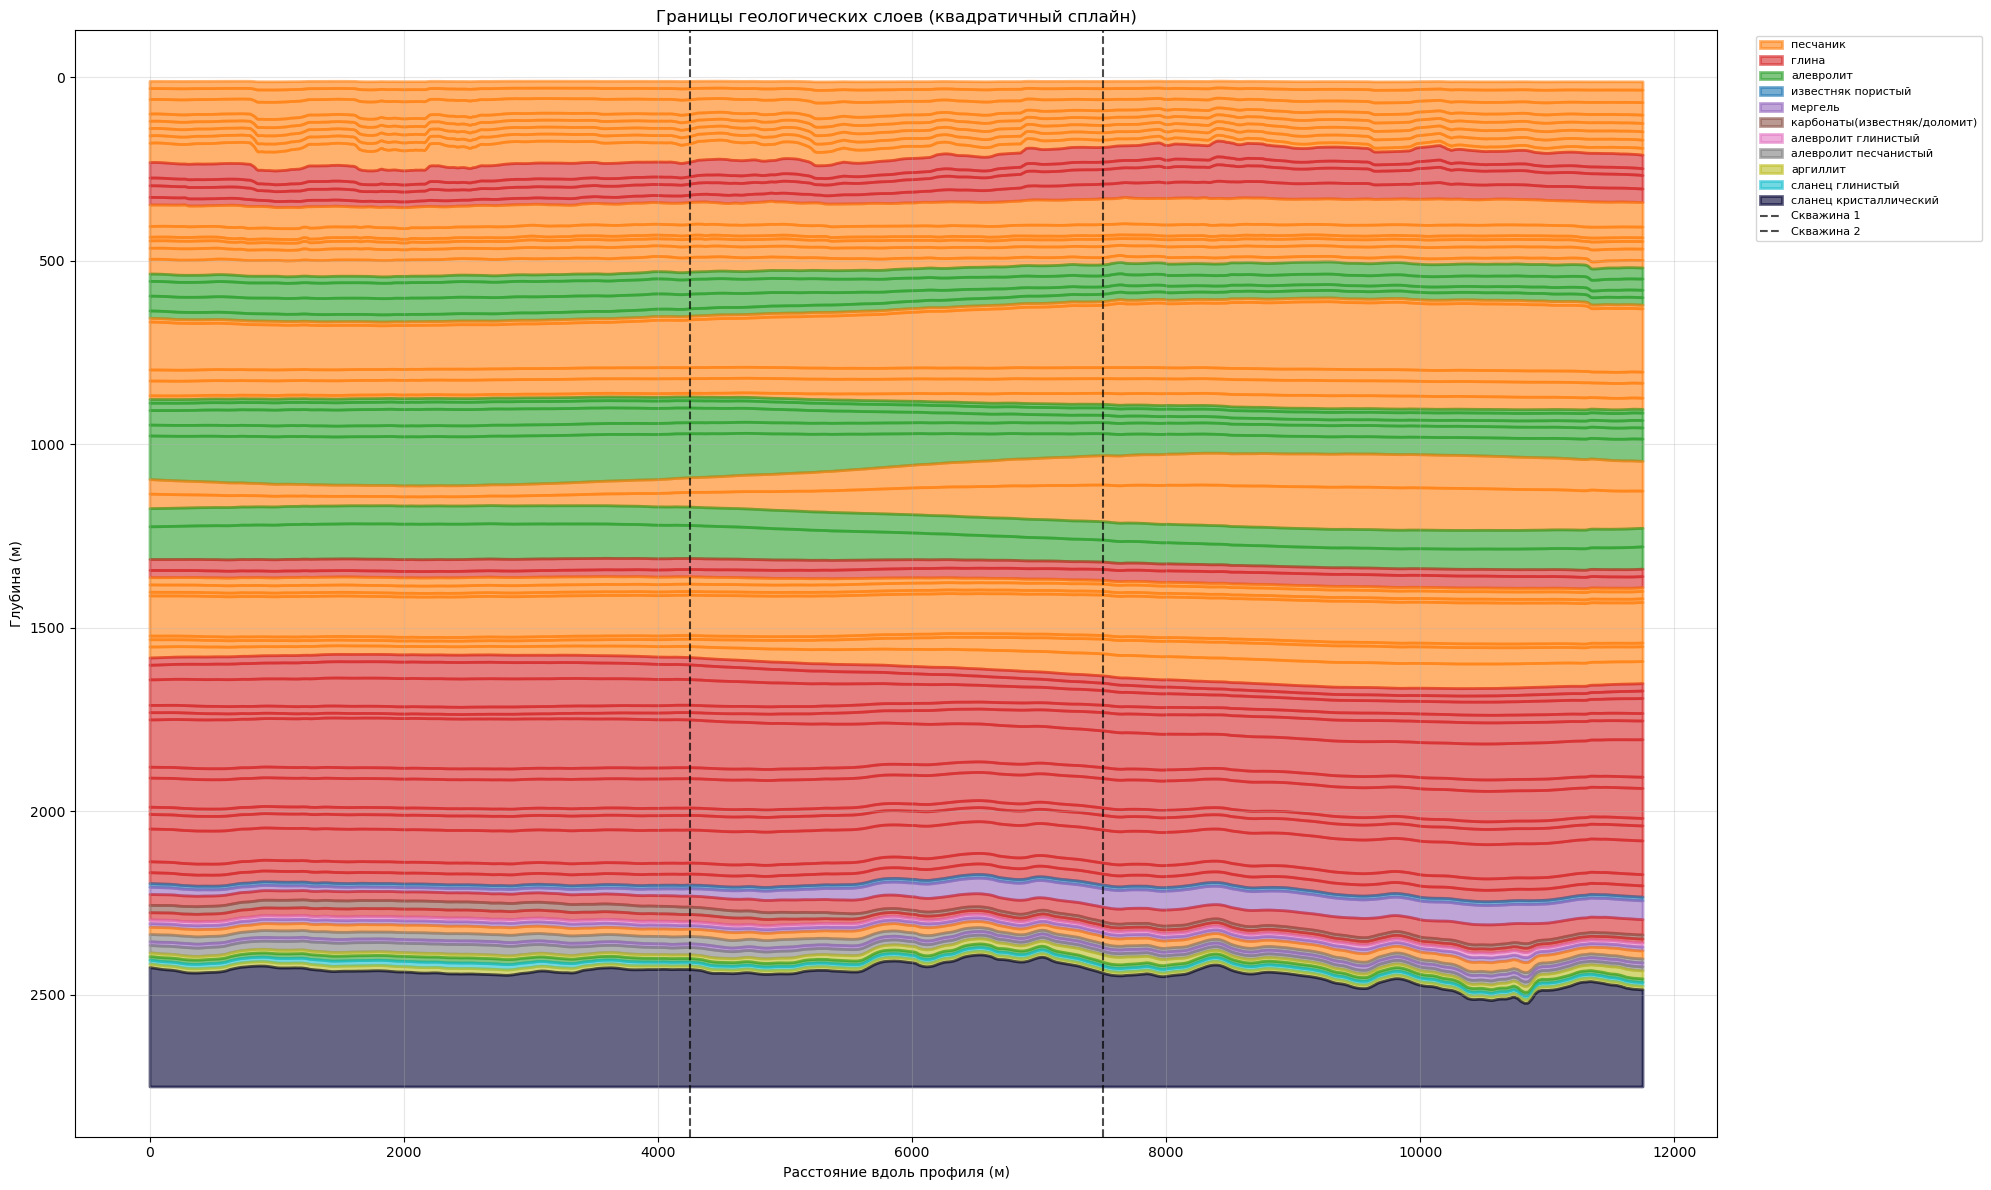


График сохранен в img/dev_1_5_2_layer_boundaries_quadratic_visualization.png


In [42]:
#%matplotlib inline
plt.figure(figsize=(20, 12))

# График сейсмических поверхностей убран по просьбе пользователя

# Границы слоев - разные цвета для разных формаций
unique_formations = list(set(layer['formation'] for layer in layer_boundaries))
print(f"Уникальных формаций: {len(unique_formations)}")

# Явная карта формация-цвет для стабильности и предсказуемости
formation_color_map = {
    'песчаник': '#ff7f0e',          # оранжевый
    'глина': '#d62728',             # красный
    'алевролит': '#2ca02c',         # зеленый
    'известняк пористый': '#1f77b4', # синий
    'мергель': '#9467bd',           # фиолетовый
    'карбонаты(известняк/доломит)': '#8c564b', # коричневый
    'алевролит глинистый': '#e377c2', # розовый
    'алевролит песчанистый': '#7f7f7f', # серый
    'аргиллит': '#bcbd22',          # оливковый
    'сланец глинистый': '#17becf',   # голубой
    'сланец кристаллический': '#000033' # темно-синий
}

# Создаем словарь цветов для найденных формаций
formation_colors = {}
for formation in unique_formations:
    if formation in formation_color_map:
        formation_colors[formation] = formation_color_map[formation]
    else:
        # Для неизвестных формаций используем случайный цвет
        import random
        formation_colors[formation] = f'#{random.randint(0, 0xFFFFFF):06x}'

print("Карта формация-цвет:")
for formation, color in formation_colors.items():
    print(f"  {formation:25} -> {color}")

# Сортируем слои по средней глубине для правильной заливки
layer_depths_mean = []
for layer_data in layer_boundaries:
    if not np.any(np.isnan(layer_data['boundary_depths'])):
        mean_depth = np.mean(layer_data['boundary_depths'])
        layer_depths_mean.append((mean_depth, layer_data))

layer_depths_mean.sort(key=lambda x: x[0])  # Сортируем по средней глубине

# Рисуем заливку областей между слоями
legend_entries = set()
for i in range(len(layer_depths_mean) - 1):
    # Текущий и следующий слой
    _, current_layer = layer_depths_mean[i]
    _, next_layer = layer_depths_mean[i + 1]

    # Заливаем цветом нижнего слоя (next_layer)
    formation = next_layer['formation']
    color = formation_colors[formation]

    # Заливаем область между текущим и следующим слоем
    plt.fill_between(distances,
                    current_layer['boundary_depths'],
                    next_layer['boundary_depths'],
                    color=color, alpha=0.6, linewidth=2.0, edgecolor=color)

    # Добавляем в легенду только если еще не добавлено
    if formation not in legend_entries:
        plt.fill_between([], [], [], color=color, alpha=0.6, linewidth=2.0, label=formation)
        legend_entries.add(formation)


# Скважины
plt.axvline(WELL1_DISTANCE, color='black', linestyle='--', alpha=0.7, label='Скважина 1')
plt.axvline(WELL2_DISTANCE, color='black', linestyle='--', alpha=0.7, label='Скважина 2')

# Маркеры скважин убраны по просьбе пользователя

plt.xlabel('Расстояние вдоль профиля (м)')
plt.ylabel('Глубина (м)')
plt.title('Границы геологических слоев (квадратичный сплайн)')

# Легенда в одну колонку
plt.legend(loc='upper left', bbox_to_anchor=(1.02, 1), ncol=1, fontsize=8)
plt.grid(True, alpha=0.3)
plt.gca().invert_yaxis()  # Инвертируем Y для геологической ориентации

plt.tight_layout()
plt.savefig('img/dev_1_5_2_layer_boundaries_quadratic_visualization.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nГрафик сохранен в img/dev_1_5_2_layer_boundaries_quadratic_visualization.png")

### Выводы

В первой задаче главы V был выполнен парсинг геологических слоев из файла wells_geometry_sketch_corr_.xlsx.

Были выполнены следующие задачи:
1. Анализ Excel файла с выделением жирным шрифтом границ слоев
2. Парсинг названий формаций и глубин границ для обеих скважин
3. Создание структурированного списка из 75 геологических слоев


Во второй задаче главы V была построена геометрия границ слоев с использованием квадратичного сплайна.

Были выполнены следующие задачи:
1. Загрузка данных геологических слоев из предыдущей задачи
2. Загрузка сейсмических поверхностей из profile_sections_depths.npz
3. Создание функций конвертации между локальными и глобальными координатами
4. Построение границ слоев через квадратичный сплайн по четырем точкам
5. Визуализация результатов с цветовой заливкой формаций

Результаты сохранены в файлах:
- data/dev_1_5_2_layer_boundaries_quadratic.npz - геометрия границ слоев
- img/dev_1_5_2_layer_boundaries_quadratic_visualization.png - визуализация слоев

## Задача 3 ##

Построить сплайны в формате fds

In [43]:
z_data = layer_boundaries_array[:, ::5]
x_data = np.zeros((76, 236))

x_data[:] = distances[::5]

vertex_coords = np.zeros((76, 236, 3))

vertex_coords[1:,:,1] = z_data
vertex_coords[:,:,0] = x_data

Создадим скрипт: data/dev_1_5_model_vertex.jou и dev_1_5_model_spline.jou

In [44]:
WELL1_X = int(WELL1_DISTANCE/50)
WELL2_X = int(WELL2_DISTANCE/50)

vertex_in_line = vertex_coords.shape[1]

vertex_coords.shape, WELL1_X, WELL2_X

((76, 236, 3), 85, 150)

Теперь мы составляем jou файл. Это позволяет сделать в fidesys его командами сплайновую модель со слоями нужной конфигурации. Для удобства отделим ту часть, которая между скважин от той, которая вне их.

In [45]:
with open('data/dev_1_5_model_vertex.jou', 'w') as f:
    f.write(f'reset\n')

    for curve_id in range(vertex_coords.shape[0]):

        for v in vertex_coords[curve_id]:
            f.write(f'create vertex location {v[0]} {v[1]} {v[2]}\n')

with open('data/dev_1_5_model_spline.jou', 'w') as f:
    for curve_id in range(vertex_coords.shape[0]):

        v_start = vertex_in_line*curve_id+1
        v_end = v_start + vertex_in_line - 1

        v_indexs = f'vertex {v_start} to {v_start+WELL1_X}'
        f.write(f'create curve spline location {v_indexs}\n')

        v_indexs = f'vertex {v_start+WELL1_X} to {v_start+WELL2_X}'
        f.write(f'create curve spline location {v_indexs}\n')

        v_indexs = f'vertex {v_start+WELL2_X} to {v_end}'
        f.write(f'create curve spline location {v_indexs}\n')

    f.write(f'delete vertex all\n')

    for surf_id in range(vertex_coords.shape[0]-1):
        f.write(f'create surface skin curve {3*surf_id+1} {3*surf_id+4}\n')
        f.write(f'create surface skin curve {3*surf_id+2} {3*surf_id+5}\n')
        f.write(f'create surface skin curve {3*surf_id+3} {3*surf_id+6}\n')
    
    f.write(f'delete curve all\n')
    f.write('merge curve all\n')
    f.write('compress curve all\n')


Мы будем строить в Fidesys сложную адаптивную сетку, максимальная величина допустимого слоя зависит от глубины. 

UPDЖ Ниже представлен старый, не совсем верный скрипт этого построения. Новый скрипт посмотрите в 1.7

Строим сетку методами map (стурктурированные слои) и pave (нестуктурированные слои)

/home/antonov/Base/Research/MilenSem2D/data/dev_1_5_model_mesh_curve.jou

In [46]:
with open('data/dev_1_5_model_mesh_curve.jou', 'w') as f:
    f.write(f'delete mesh surface all propagate\n')
    f.write(f'delete mesh curve all propagate\n')

    for curve_id in [1, 3] + list(range(12,524,7)):
        f.write(f'curve {curve_id} scheme equal interval 425\n')

    for curve_id in [5, 7] + list(range(15,527,7)):
        f.write(f'curve {curve_id} scheme equal interval 325\n')

    for curve_id in [8, 10] + list(range(17,529,7)):
        f.write(f'curve {curve_id} scheme equal interval 425\n')

    for i, curve_id in enumerate([2] + list(range(13,525,7)) ):
        f.write(f'curve {curve_id} scheme equal interval {layer_count_depth_left[i]}\n')

    for i, curve_id in enumerate([4] + list(range(11,523,7))):
        f.write(f'curve {curve_id} scheme equal interval {layer_count_depth_left[i]}\n')

    for i, curve_id in enumerate([6] + list(range(14,526,7)) ):
        f.write(f'curve {curve_id} scheme equal interval {layer_count_depth_right[i]}\n')

    for i, curve_id in enumerate([9] + list(range(16,528,7)) ):
        f.write(f'curve {curve_id} scheme equal interval {layer_count_depth_right[i]}\n')

    f.write(f'mesh curve all\n')


Все эти скрипты после генерации нужно запустить в fidesys. Это создаст геометрию и почти всю сетку модели. 

In [47]:
with open('data/dev_1_5_model_mesh_surface.jou', 'w') as f:
    f.write(f'delete mesh surface all\n')
    for surf_id in range(1,224,3):
        f.write(f'surface {surf_id} scheme map\n')
        f.write(f'mesh surface {surf_id}\n')
    for surf_id in range(3,226,3):
        f.write(f'surface {surf_id} scheme map\n')
        f.write(f'mesh surface {surf_id}\n')
    for i, surf_id in enumerate(range(2,225,3)):
        if layer_count_depth_left[i] == layer_count_depth_right[i]:
            f.write(f'surface {surf_id} scheme map\n')
        else:
            f.write(f'surface {surf_id} scheme pave\n')
        f.write(f'mesh surface {surf_id}\n')


Далее мы поговорим о материале и гранусловиях.